<a href="https://www.kaggle.com/code/omborse771924/discogs-vinyl-records-2026-eda?scriptVersionId=332158102" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uradkr/discogs-vinyl-records-market-intelligence-2026/discogs_vinyl_records_market_intelligence_2026.csv


## loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/uradkr/discogs-vinyl-records-market-intelligence-2026/discogs_vinyl_records_market_intelligence_2026.csv')

In [3]:
df.head()

,release_id,master_id,artist,title,year,country,genre,style,label,catalog_number,...,want_have_ratio,decade,is_various_artists,is_listed,primary_genre,primary_style,scrape_date,price_outlier_flag,price_tier,collector_heat_score
0,4686625,661985.0,The Dear Hunter,The Color Spectrum Complete Collection,2011.0,US,Rock,"Alternative Rock, Prog Rock, Experimental",Triple Crown Records,none,...,1.895131,2010s,False,True,Rock,Alternative Rock,2026-06-22,True,Collector ($100+),3.81
1,10509970,661985.0,The Dear Hunter,The Color Spectrum Complete Collection,2017.0,US,Rock,"Alternative Rock, Prog Rock, Experimental",Triple Crown Records,none,...,0.851272,2010s,False,True,Rock,Alternative Rock,2026-06-22,True,Collector ($100+),1.71
2,20161255,NaN,Various,Flying Vinyl July 2021,2021.0,UK,Rock,"Alternative Rock, Indie Rock",Flying Vinyl (2),Issue 77,...,0.320000,2020s,True,False,Rock,Alternative Rock,2026-06-22,False,Not Listed,0.33
3,3853861,NaN,Resentment,Demo,2006.0,Croatia,Rock,Death Metal,Not On Label,none,...,1.000000,2000s,False,False,Rock,Death Metal,2026-06-22,False,Not Listed,1.04
4,3829435,962085.0,Belles Will Ring,Crystal Theatre,2011.0,Australia,Rock,"Psychedelic Rock, Indie Rock",Dot Dash,DASH018LP,...,0.441860,2010s,False,False,Rock,Psychedelic Rock,2026-06-22,False,Not Listed,0.85


In [4]:
df.tail()

,release_id,master_id,artist,title,year,country,genre,style,label,catalog_number,...,want_have_ratio,decade,is_various_artists,is_listed,primary_genre,primary_style,scrape_date,price_outlier_flag,price_tier,collector_heat_score
2495,3530251,NaN,Harrison Brothers,Sexy Lady / Harrison Special,1983.0,US,Funk / Soul,Funk,H.B.S.E.,HBS-45-01,...,3.442308,1980s,False,True,Funk / Soul,Funk,2026-06-22,True,Premium ($20-100),6.91
2496,3069864,NaN,Hazy Osterwald Sextett,Jet - Set,1972.0,Belgium,Funk / Soul,NaN,Disco (5),D. 16902,...,1.540000,1970s,False,True,Funk / Soul,NaN,2026-06-22,False,Mid ($5-20),2.95
2497,5218514,2443996.0,Roscoe Robinson,Heavenly Soul Music,1981.0,Japan,Funk / Soul,Soul,P-Vine Special,PLP-719,...,0.692308,1980s,False,True,Funk / Soul,Soul,2026-06-22,False,Mid ($5-20),1.43
2498,2581685,785130.0,Bill Withers,Lean On Me,1989.0,Austria,Funk / Soul,Soul,CBS,654885 7,...,0.764706,1980s,False,True,Funk / Soul,Soul,2026-06-22,False,Mid ($5-20),1.37
2499,3892786,183112.0,Stevie Wonder,Gotta Have You,1991.0,Germany,Funk / Soul,New Jack Swing,Motown,ZT44270,...,0.215686,1990s,False,True,Funk / Soul,New Jack Swing,2026-06-22,False,Budget (<$5),0.45


In [5]:
df.describe()

,release_id,master_id,year,num_tracks,lowest_price_usd,num_for_sale,community_have,community_want,rating_avg,rating_count,want_have_ratio,collector_heat_score
count,2.500000e+03,1.853000e+03,2205.000000,2500.000000,2283.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2489.000000,2500.000000
mean,6.739719e+06,9.372618e+05,1992.414966,8.545600,19.615125,11.185200,140.129200,79.473600,3.895244,14.429600,0.865638,1.621256
std,7.512204e+06,9.040882e+05,17.854998,9.729018,77.390937,11.793937,198.657667,148.752714,1.290956,26.268572,1.958407,3.643071
min,1.461000e+03,1.320000e+02,1949.000000,1.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.604304e+06,3.357490e+05,1978.000000,3.000000,2.590000,3.000000,42.000000,8.000000,3.857500,2.000000,0.148148,0.267500
50%,4.329926e+06,6.589050e+05,1992.000000,8.000000,5.750000,8.000000,66.000000,26.000000,4.250000,5.000000,0.369914,0.690000
75%,7.521084e+06,1.211203e+06,2006.000000,12.000000,15.660000,15.000000,124.000000,84.000000,4.600000,12.000000,0.833333,1.570000
max,3.756888e+07,4.249410e+06,2026.000000,311.000000,2182.760000,97.000000,2186.000000,2182.000000,5.000000,341.000000,53.666667,100.000000


In [6]:
df.isnull()

,release_id,master_id,artist,title,year,country,genre,style,label,catalog_number,...,want_have_ratio,decade,is_various_artists,is_listed,primary_genre,primary_style,scrape_date,price_outlier_flag,price_tier,collector_heat_score
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2496,False,True,False,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
2497,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

release_id                0
master_id               647
artist                    0
title                     0
year                    295
country                  68
genre                     0
style                   651
label                     0
catalog_number            0
format                    0
format_detail            45
num_tracks                0
lowest_price_usd        217
num_for_sale              0
community_have            0
community_want            0
rating_avg                0
rating_count              0
data_quality             30
date_added                0
date_changed              0
want_have_ratio          11
decade                  295
is_various_artists        0
is_listed                 0
primary_genre             0
primary_style           651
scrape_date               0
price_outlier_flag        0
price_tier                0
collector_heat_score      0
dtype: int64

In [8]:
# ==========================================================
# HANDLE MISSING VALUES
# ==========================================================

import pandas as pd
import numpy as np

# --------------------------
# Check Missing Values
# --------------------------

print("Missing Values Before:")
print(df.isnull().sum())

# --------------------------
# Numerical Columns
# --------------------------

numeric_columns = [
    'release_id',
    'master_id',
    'year',
    'num_tracks',
    'lowest_price_usd',
    'num_for_sale',
    'community_have',
    'community_want',
    'rating_avg',
    'rating_count',
    'want_have_ratio',
    'collector_heat_score'
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# --------------------------
# Categorical Columns
# --------------------------

categorical_columns = [
    'artist',
    'title',
    'country',
    'genre',
    'style',
    'label',
    'catalog_number',
    'format',
    'format_detail',
    'data_quality',
    'date_added',
    'date_changed',
    'decade',
    'is_various_artists',
    'is_listed',
    'primary_genre',
    'primary_style',
    'scrape_date',
    'price_outlier_flag',
    'price_tier'
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# --------------------------
# Verify Missing Values
# --------------------------

print("\nMissing Values After:")
print(df.isnull().sum())

# --------------------------
# Dataset Information
# --------------------------

print("\nDataset Shape :", df.shape)

print("\nData Types")
print(df.dtypes)

print("\nAny Missing Values Left?")
print(df.isnull().sum().sum())

Missing Values Before:
release_id                0
master_id               647
artist                    0
title                     0
year                    295
country                  68
genre                     0
style                   651
label                     0
catalog_number            0
format                    0
format_detail            45
num_tracks                0
lowest_price_usd        217
num_for_sale              0
community_have            0
community_want            0
rating_avg                0
rating_count              0
data_quality             30
date_added                0
date_changed              0
want_have_ratio          11
decade                  295
is_various_artists        0
is_listed                 0
primary_genre             0
primary_style           651
scrape_date               0
price_outlier_flag        0
price_tier                0
collector_heat_score      0
dtype: int64

Missing Values After:
release_id              0
master_id          

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2495    False
2496    False
2497    False
2498    False
2499    False
Length: 2500, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['release_id', 'master_id', 'artist', 'title', 'year', 'country',
       'genre', 'style', 'label', 'catalog_number', 'format', 'format_detail',
       'num_tracks', 'lowest_price_usd', 'num_for_sale', 'community_have',
       'community_want', 'rating_avg', 'rating_count', 'data_quality',
       'date_added', 'date_changed', 'want_have_ratio', 'decade',
       'is_various_artists', 'is_listed', 'primary_genre', 'primary_style',
       'scrape_date', 'price_outlier_flag', 'price_tier',
       'collector_heat_score'],
      dtype='object')

## EDA

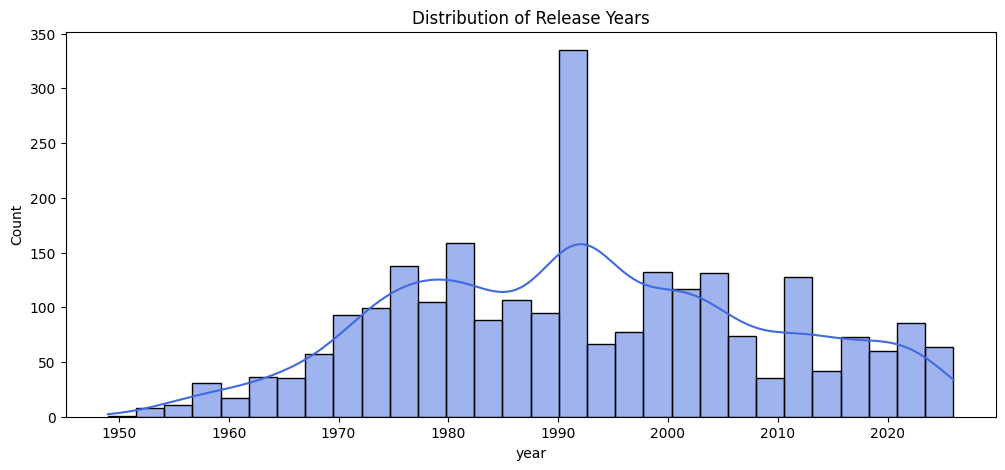

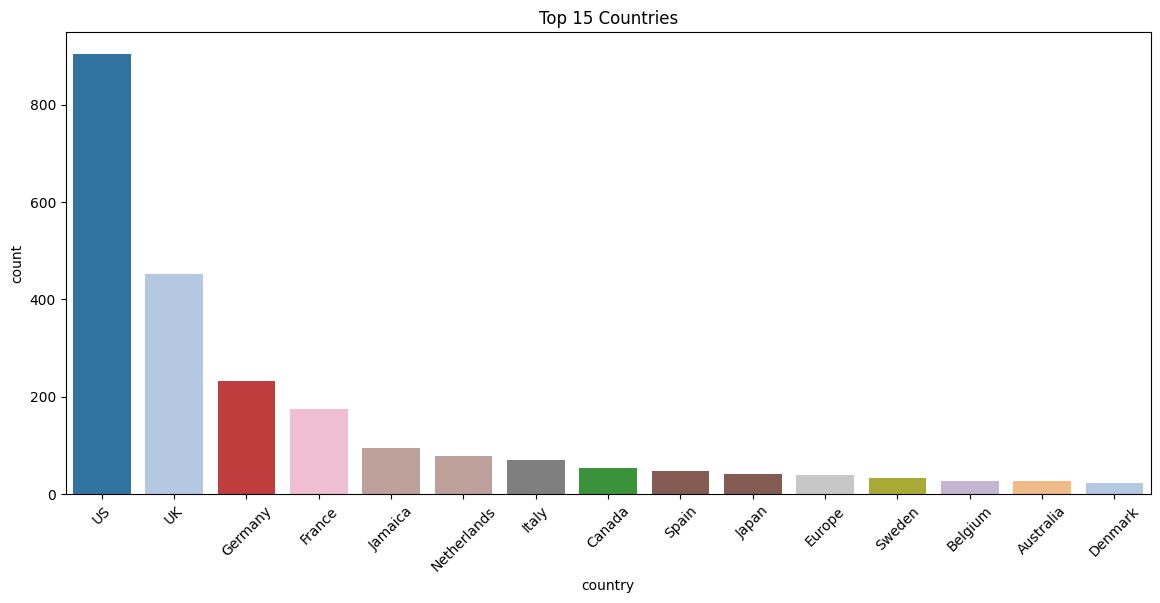

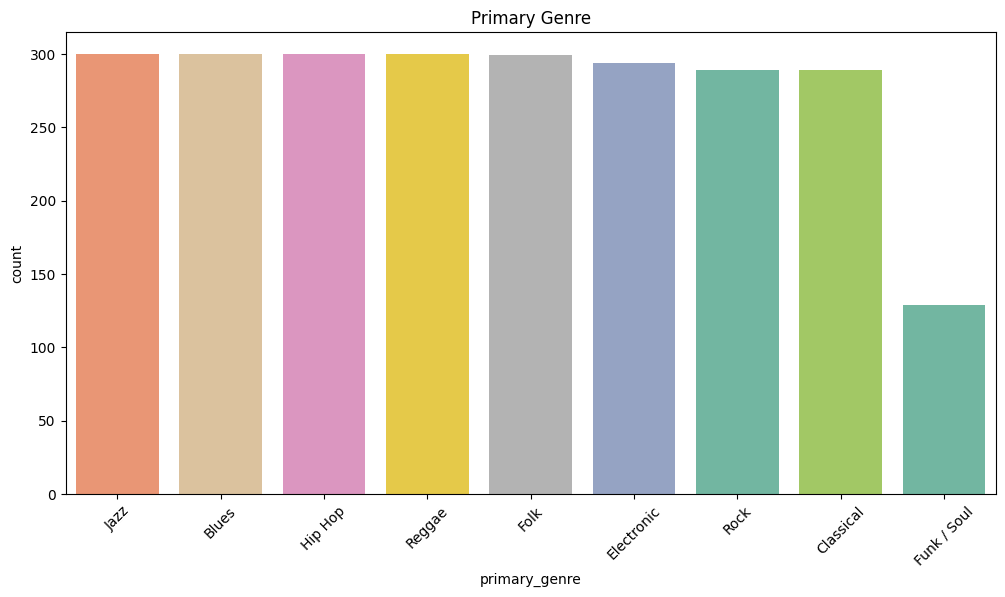

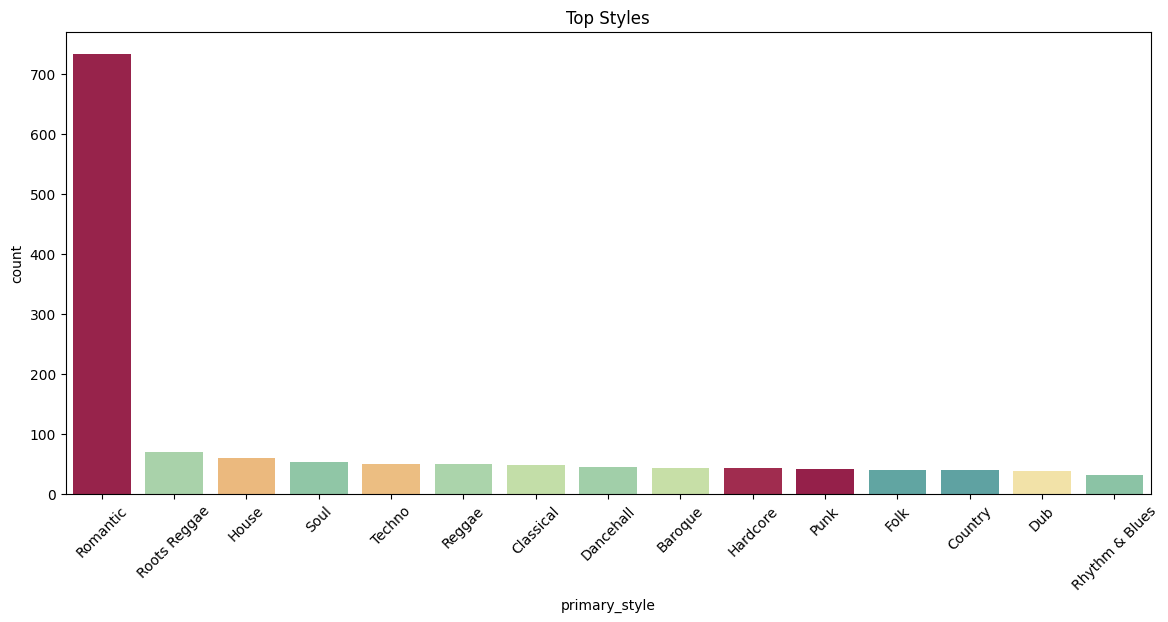

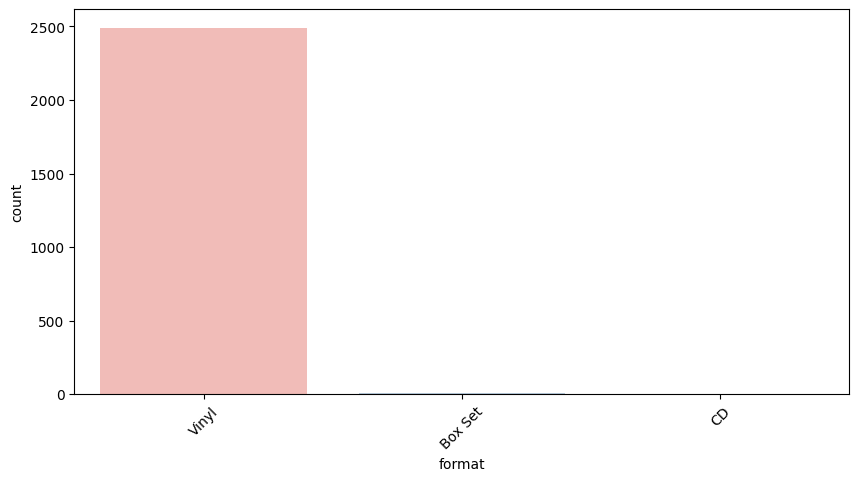

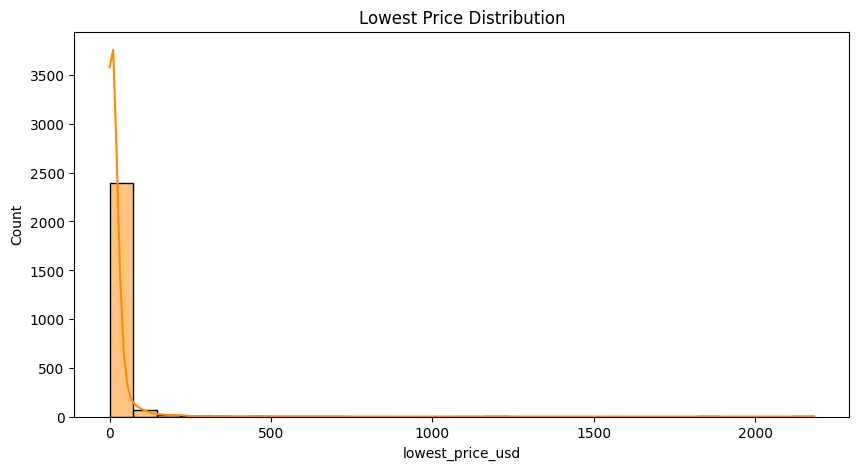

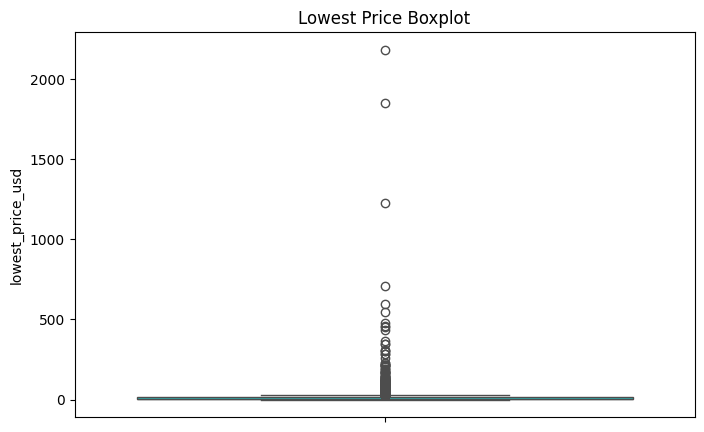

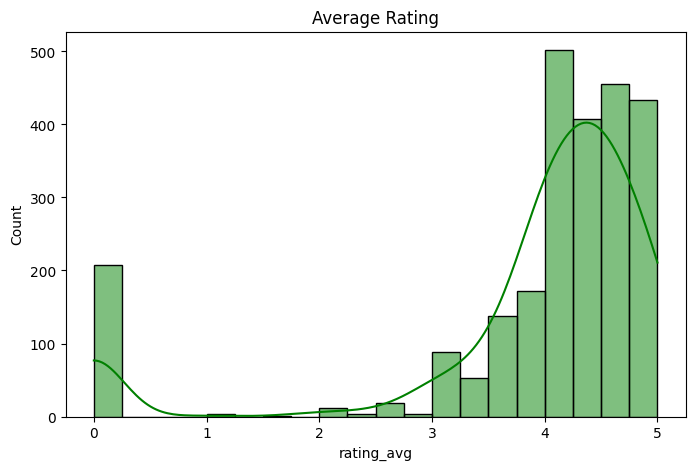

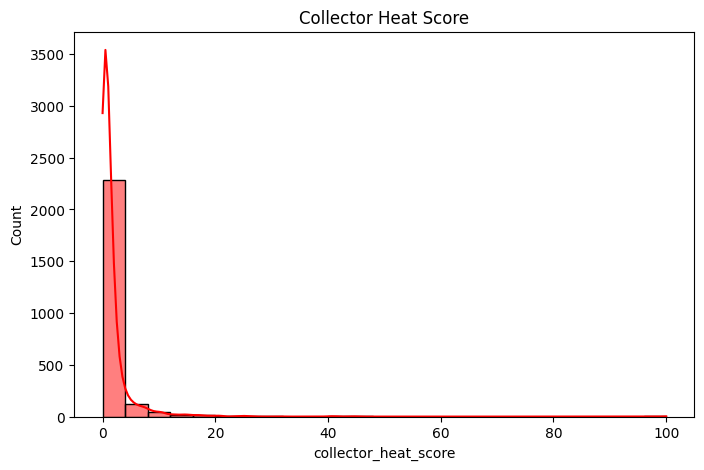

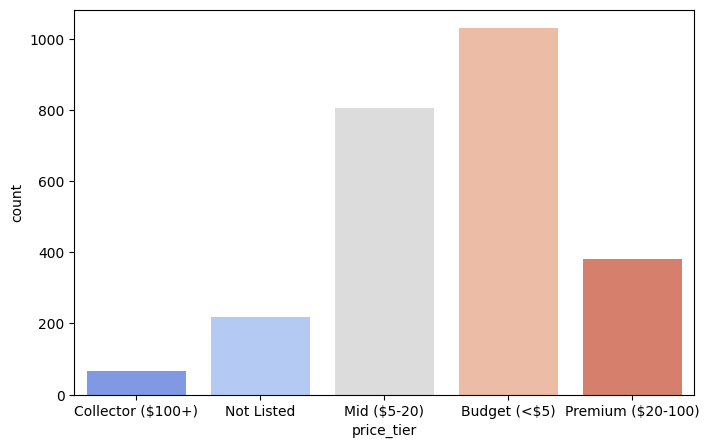

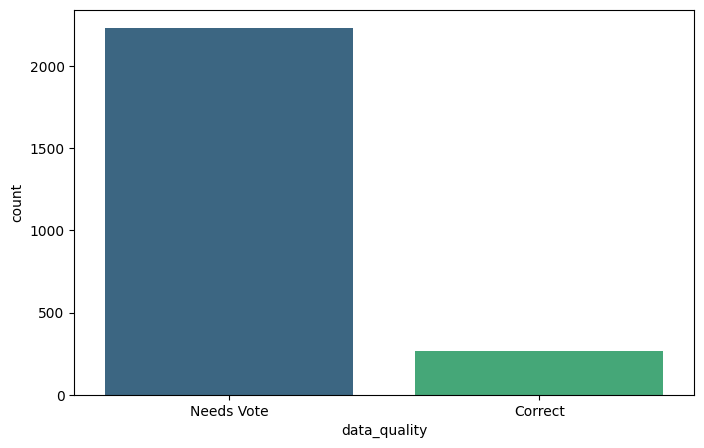

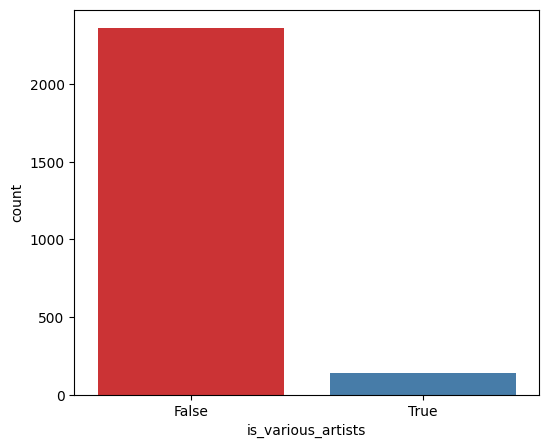

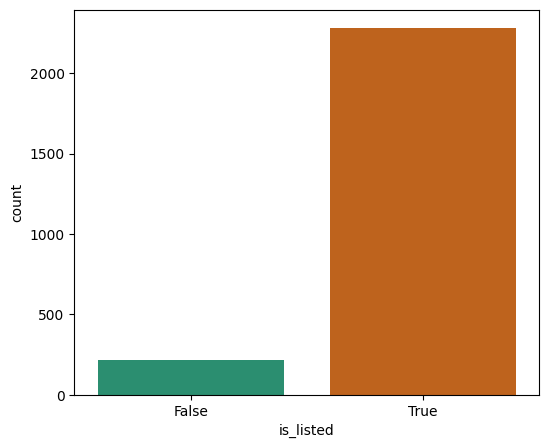

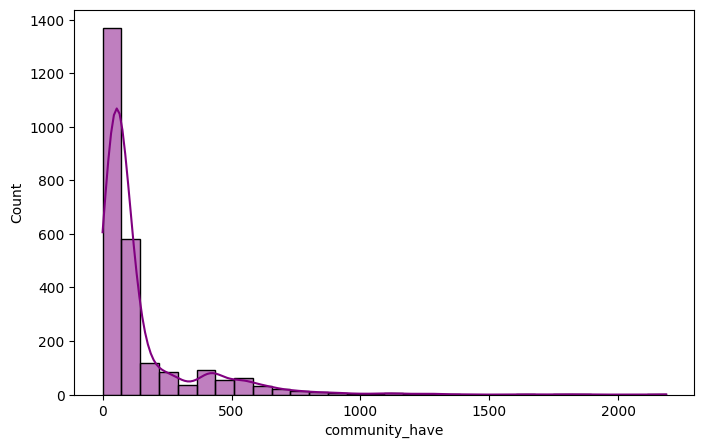

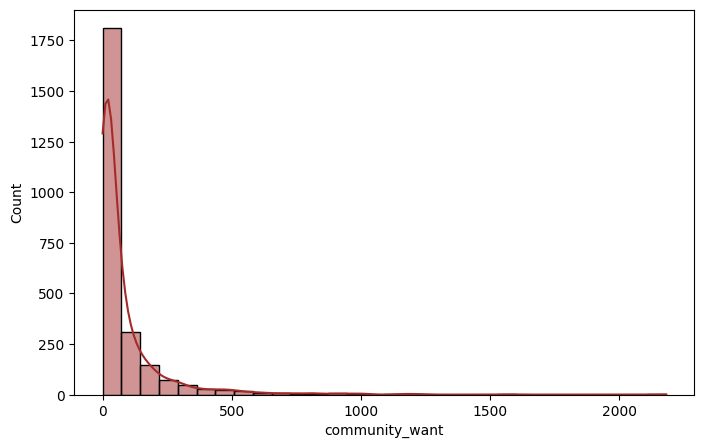

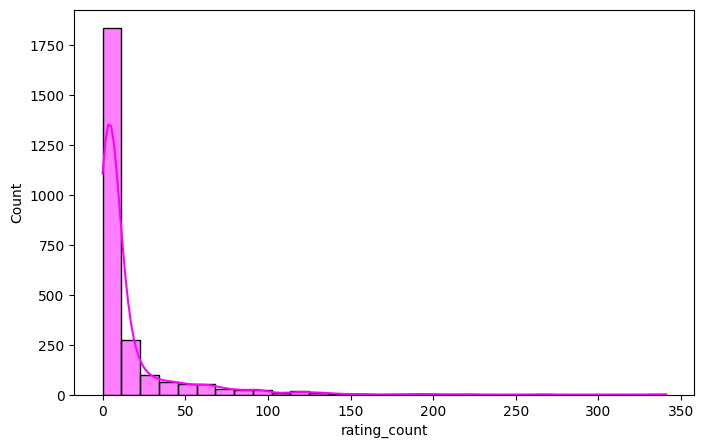

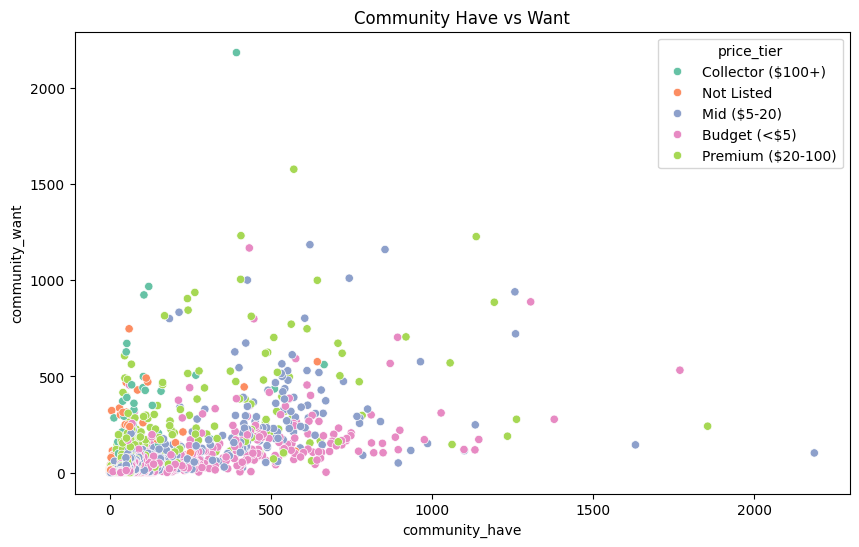

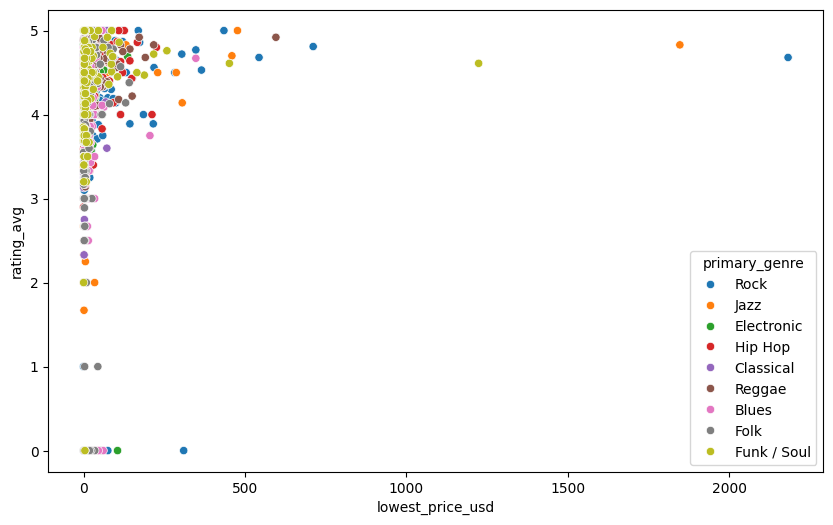

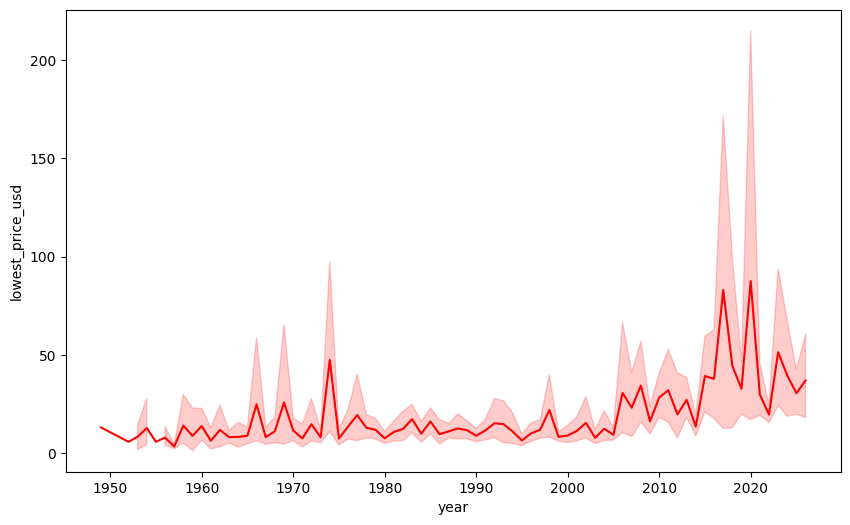

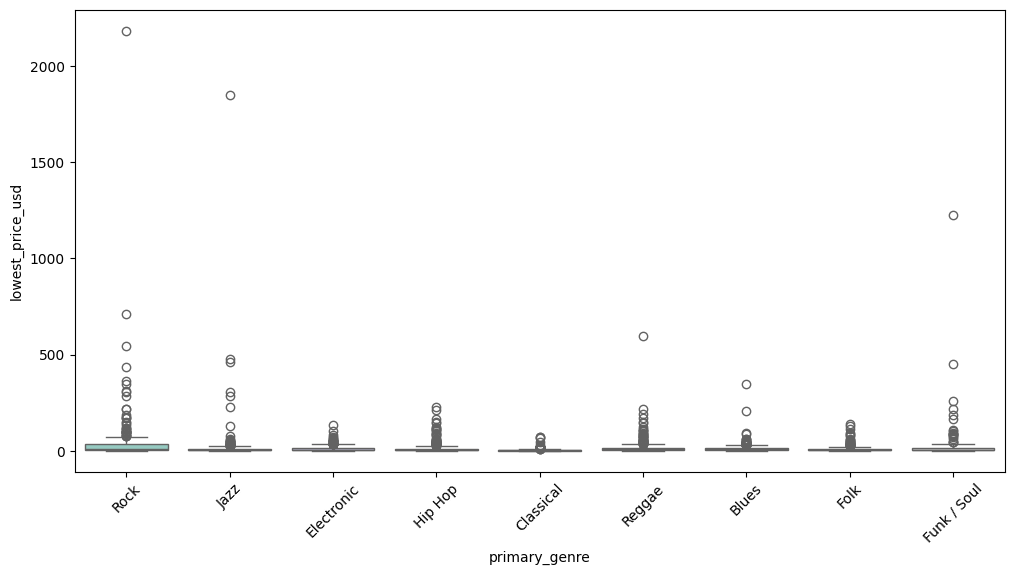

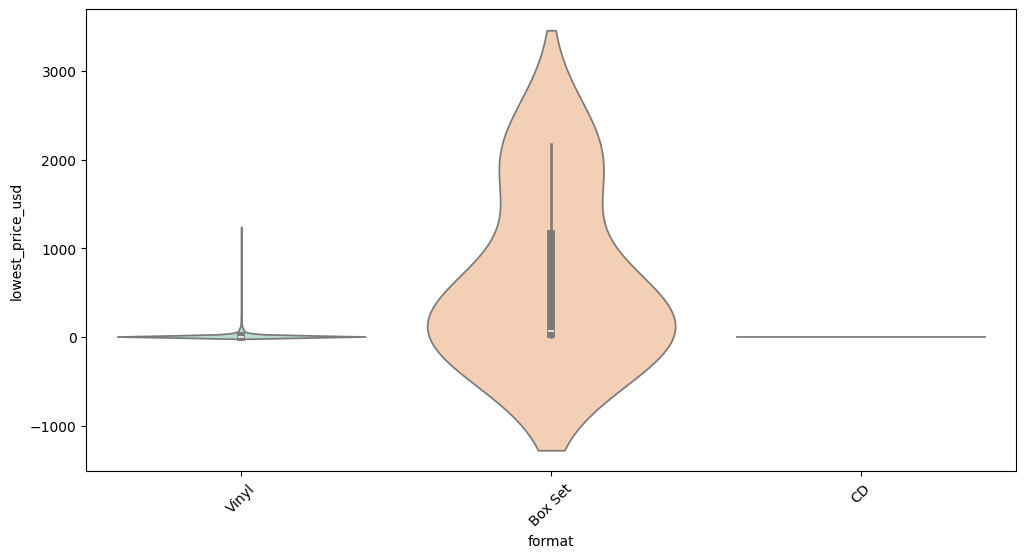

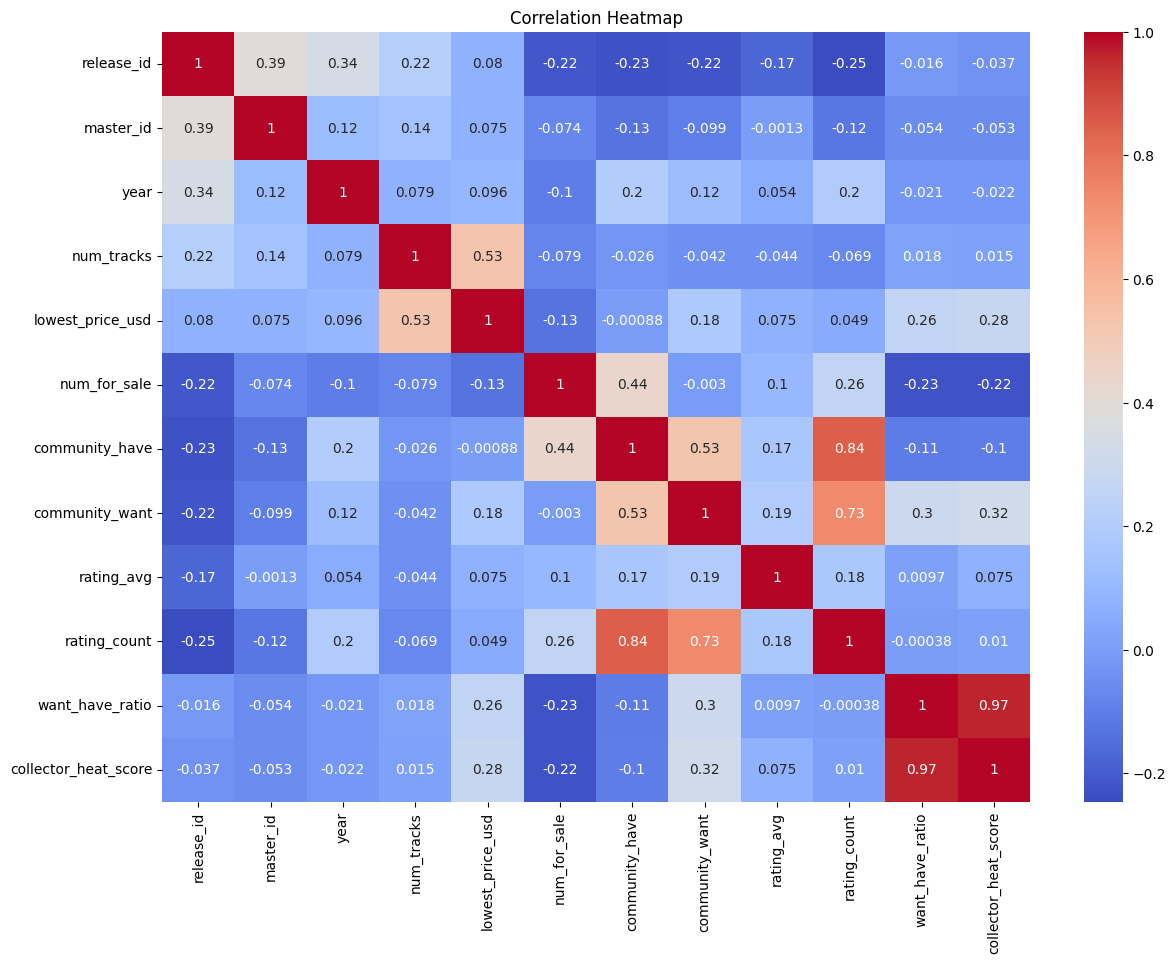

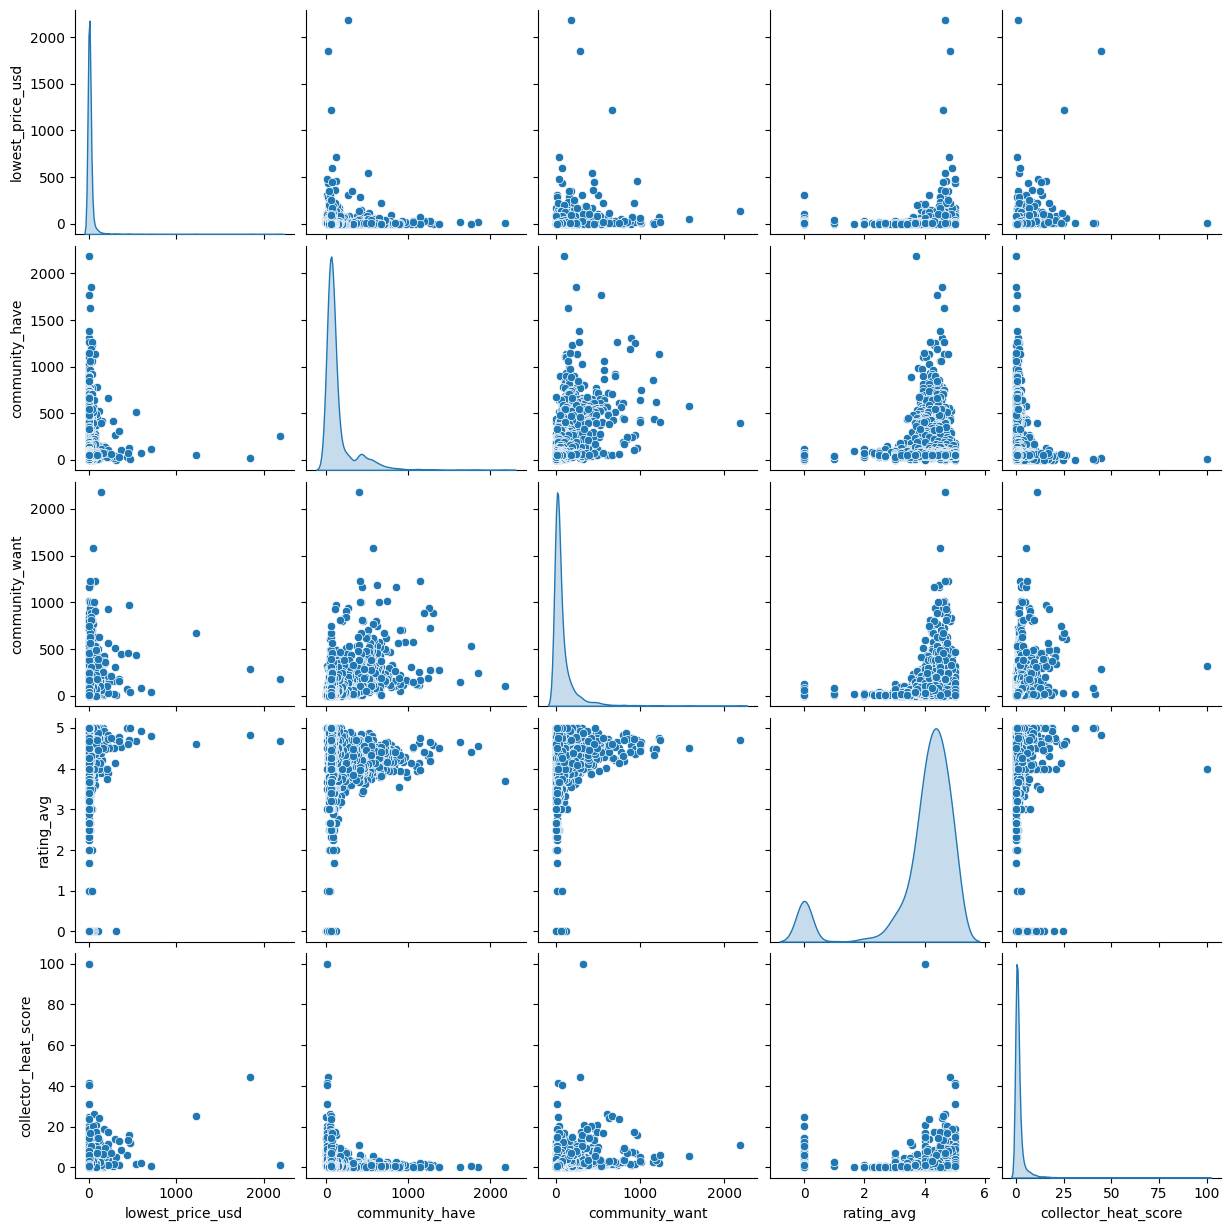

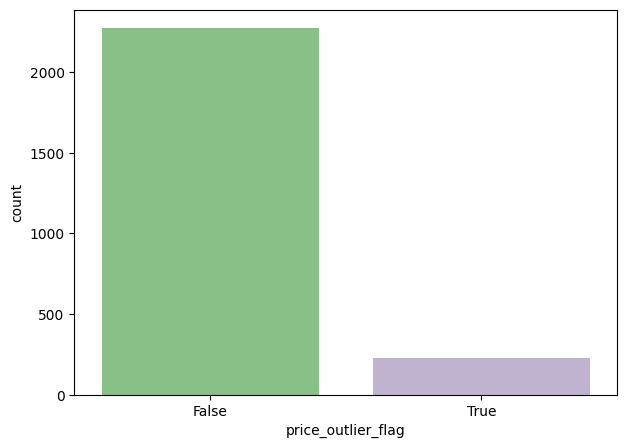

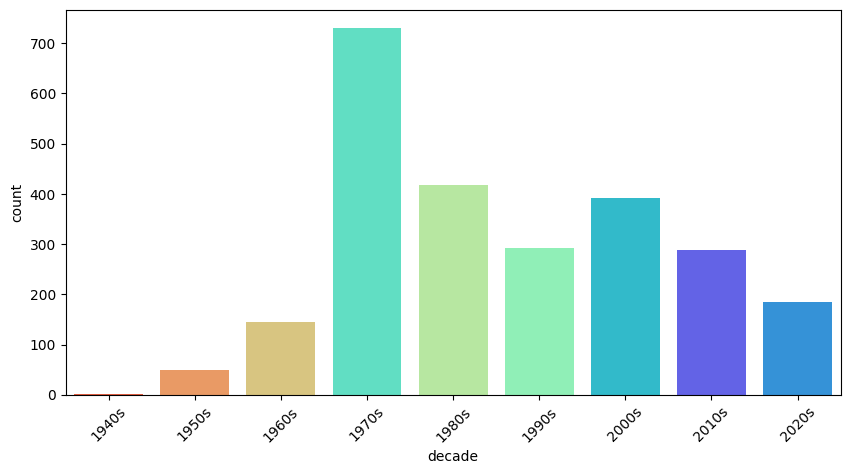

In [12]:
plt.rcParams["figure.figsize"]=(10,6)

# ===========================
# 1. Year Distribution
# ===========================
plt.figure(figsize=(12,5))
sns.histplot(df['year'], bins=30, kde=True, color='royalblue')
plt.title("Distribution of Release Years")
plt.show()

# ===========================
# 2. Country Distribution
# ===========================
plt.figure(figsize=(14,6))
sns.countplot(
    data=df,
    x='country',
    order=df['country'].value_counts().head(15).index,
    hue='country',
    palette='tab20',
    legend=False
)
plt.xticks(rotation=45)
plt.title("Top 15 Countries")
plt.show()

# ===========================
# 3. Genre Distribution
# ===========================
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x='primary_genre',
    order=df['primary_genre'].value_counts().index,
    hue='primary_genre',
    palette='Set2',
    legend=False
)
plt.xticks(rotation=45)
plt.title("Primary Genre")
plt.show()

# ===========================
# 4. Style Distribution
# ===========================
plt.figure(figsize=(14,6))
sns.countplot(
    data=df,
    x='primary_style',
    order=df['primary_style'].value_counts().head(15).index,
    hue='primary_style',
    palette='Spectral',
    legend=False
)
plt.xticks(rotation=45)
plt.title("Top Styles")
plt.show()

# ===========================
# 5. Format
# ===========================
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x='format',
    hue='format',
    palette='Pastel1',
    legend=False
)
plt.xticks(rotation=45)
plt.show()

# ===========================
# 6. Price Distribution
# ===========================
plt.figure(figsize=(10,5))
sns.histplot(df['lowest_price_usd'], bins=30, kde=True, color='darkorange')
plt.title("Lowest Price Distribution")
plt.show()

# ===========================
# 7. Boxplot Price
# ===========================
plt.figure(figsize=(8,5))
sns.boxplot(y=df['lowest_price_usd'], color='cyan')
plt.title("Lowest Price Boxplot")
plt.show()

# ===========================
# 8. Rating Distribution
# ===========================
plt.figure(figsize=(8,5))
sns.histplot(df['rating_avg'], bins=20, kde=True, color='green')
plt.title("Average Rating")
plt.show()

# ===========================
# 9. Collector Heat Score
# ===========================
plt.figure(figsize=(8,5))
sns.histplot(df['collector_heat_score'], bins=25, kde=True, color='red')
plt.title("Collector Heat Score")
plt.show()

# ===========================
# 10. Price Tier
# ===========================
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='price_tier',
    hue='price_tier',
    palette='coolwarm',
    legend=False
)
plt.show()

# ===========================
# 11. Data Quality
# ===========================
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='data_quality',
    hue='data_quality',
    palette='viridis',
    legend=False
)
plt.show()

# ===========================
# 12. Various Artists
# ===========================
plt.figure(figsize=(6,5))
sns.countplot(
    data=df,
    x='is_various_artists',
    hue='is_various_artists',
    palette='Set1',
    legend=False
)
plt.show()

# ===========================
# 13. Listed
# ===========================
plt.figure(figsize=(6,5))
sns.countplot(
    data=df,
    x='is_listed',
    hue='is_listed',
    palette='Dark2',
    legend=False
)
plt.show()

# ===========================
# 14. Community Have
# ===========================
plt.figure(figsize=(8,5))
sns.histplot(df['community_have'], bins=30, color='purple', kde=True)
plt.show()

# ===========================
# 15. Community Want
# ===========================
plt.figure(figsize=(8,5))
sns.histplot(df['community_want'], bins=30, color='brown', kde=True)
plt.show()

# ===========================
# 16. Rating Count
# ===========================
plt.figure(figsize=(8,5))
sns.histplot(df['rating_count'], bins=30, color='magenta', kde=True)
plt.show()

# ===========================
# 17. Scatter Plot
# ===========================
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='community_have',
    y='community_want',
    hue='price_tier',
    palette='Set2'
)
plt.title("Community Have vs Want")
plt.show()

# ===========================
# 18. Price vs Rating
# ===========================
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='lowest_price_usd',
    y='rating_avg',
    hue='primary_genre',
    palette='tab10'
)
plt.show()

# ===========================
# 19. Year vs Price
# ===========================
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df,
    x='year',
    y='lowest_price_usd',
    color='red'
)
plt.show()

# ===========================
# 20. Price by Genre
# ===========================
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x='primary_genre',
    y='lowest_price_usd',
    palette='Set3'
)
plt.xticks(rotation=45)
plt.show()

# ===========================
# 21. Price by Format
# ===========================
plt.figure(figsize=(12,6))
sns.violinplot(
    data=df,
    x='format',
    y='lowest_price_usd',
    hue='format',
    palette='Pastel2',
    legend=False
)
plt.xticks(rotation=45)
plt.show()

# ===========================
# 22. Correlation Heatmap
# ===========================
plt.figure(figsize=(14,10))
num = df.select_dtypes(include=np.number)
sns.heatmap(num.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ===========================
# 23. Pairplot
# ===========================
cols=[
'lowest_price_usd',
'community_have',
'community_want',
'rating_avg',
'collector_heat_score'
]

sns.pairplot(df[cols], diag_kind='kde')
plt.show()

# ===========================
# 24. Price Outlier Flag
# ===========================
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x='price_outlier_flag',
    hue='price_outlier_flag',
    palette='Accent',
    legend=False
)
plt.show()

# ===========================
# 25. Decade Distribution
# ===========================
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x='decade',
    order=sorted(df['decade'].unique()),
    hue='decade',
    palette='rainbow',
    legend=False
)
plt.xticks(rotation=45)
plt.show()

## Features Engineering

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, label_binarize

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# ==========================================================
# TARGET COLUMN
# ==========================================================

target = "price_tier"

# ==========================================================
# REMOVE COLUMNS THAT SHOULD NOT BE USED
# ==========================================================

drop_columns = [
    "release_id",
    "master_id",
    "title",
    "catalog_number",
    "date_added",
    "date_changed",
    "scrape_date"
]

X = df.drop(columns=drop_columns + [target])
y = df[target]

# ==========================================================
# TRAIN TEST SPLIT (NO DATA LEAKAGE)
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

# ==========================================================
# NUMERIC & CATEGORICAL COLUMNS
# ==========================================================

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X_train.select_dtypes(include=["object"]).columns

print("\nNumeric Columns:")
print(list(numeric_features))

print("\nCategorical Columns:")
print(list(categorical_features))

# ==========================================================
# NUMERIC PIPELINE
# ==========================================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# ==========================================================
# CATEGORICAL PIPELINE
# ==========================================================

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ]
)

# ==========================================================
# COLUMN TRANSFORMER
# ==========================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessing Pipeline Ready!")

Training Shape : (2000, 24)
Testing Shape  : (500, 24)

Numeric Columns:
['year', 'num_tracks', 'lowest_price_usd', 'num_for_sale', 'community_have', 'community_want', 'rating_avg', 'rating_count', 'want_have_ratio', 'collector_heat_score']

Categorical Columns:
['artist', 'country', 'genre', 'style', 'label', 'format', 'format_detail', 'data_quality', 'decade', 'primary_genre', 'primary_style']

Preprocessing Pipeline Ready!




Logistic Regression
Accuracy : 0.4820
Precision: 0.5571
Recall   : 0.4820
F1 Score : 0.5093

Classification Report

                   precision    recall  f1-score   support

     Budget (<$5)       0.72      0.62      0.66       206
Collector ($100+)       0.09      0.62      0.16        13
      Mid ($5-20)       0.50      0.37      0.42       161
       Not Listed       0.35      0.32      0.33        44
Premium ($20-100)       0.43      0.43      0.43        76

         accuracy                           0.48       500
        macro avg       0.42      0.47      0.40       500
     weighted avg       0.56      0.48      0.51       500



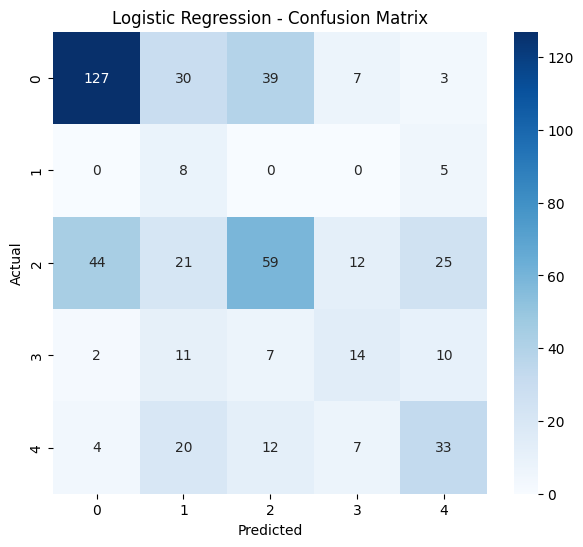



KNN
Accuracy : 0.3840
Precision: 0.4261
Recall   : 0.3840
F1 Score : 0.3364

Classification Report

                   precision    recall  f1-score   support

     Budget (<$5)       0.40      0.55      0.47       206
Collector ($100+)       0.00      0.00      0.00        13
      Mid ($5-20)       0.36      0.46      0.40       161
       Not Listed       1.00      0.02      0.04        44
Premium ($20-100)       0.38      0.04      0.07        76

         accuracy                           0.38       500
        macro avg       0.43      0.22      0.20       500
     weighted avg       0.43      0.38      0.34       500



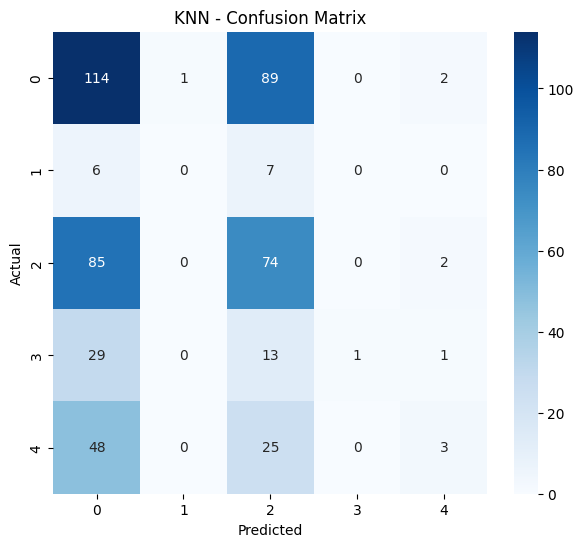



Decision Tree
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report

                   precision    recall  f1-score   support

     Budget (<$5)       1.00      1.00      1.00       206
Collector ($100+)       1.00      1.00      1.00        13
      Mid ($5-20)       1.00      1.00      1.00       161
       Not Listed       1.00      1.00      1.00        44
Premium ($20-100)       1.00      1.00      1.00        76

         accuracy                           1.00       500
        macro avg       1.00      1.00      1.00       500
     weighted avg       1.00      1.00      1.00       500



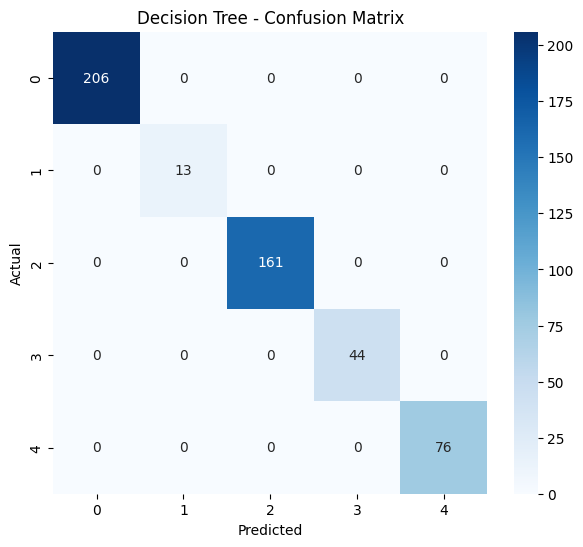



MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score
2        Decision Tree     1.000   1.000000   1.000  1.000000
0  Logistic Regression     0.482   0.557103   0.482  0.509281
1                  KNN     0.384   0.426111   0.384  0.336409


In [14]:
# =====================================================
# MACHINE LEARNING MODELS
# =====================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# =====================================================
# MODELS
# =====================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42)

}

results = []

# =====================================================
# TRAIN & TEST
# =====================================================

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Prediction
    y_pred = pipeline.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append([name, accuracy, precision, recall, f1])

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# =====================================================
# MODEL COMPARISON
# =====================================================

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(comparison)



Random Forest
Accuracy : 0.984
Precision: 0.9855238095238095
Recall   : 0.984
F1 Score : 0.9818179373667814

Classification Report

                   precision    recall  f1-score   support

     Budget (<$5)       1.00      1.00      1.00       206
Collector ($100+)       1.00      0.46      0.63        13
      Mid ($5-20)       1.00      0.99      1.00       161
       Not Listed       1.00      1.00      1.00        44
Premium ($20-100)       0.90      1.00      0.95        76

         accuracy                           0.98       500
        macro avg       0.98      0.89      0.92       500
     weighted avg       0.99      0.98      0.98       500



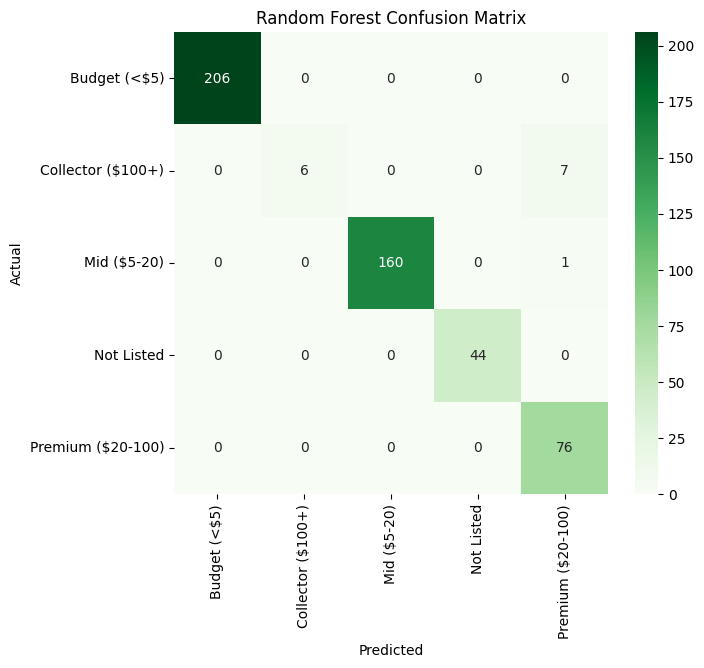

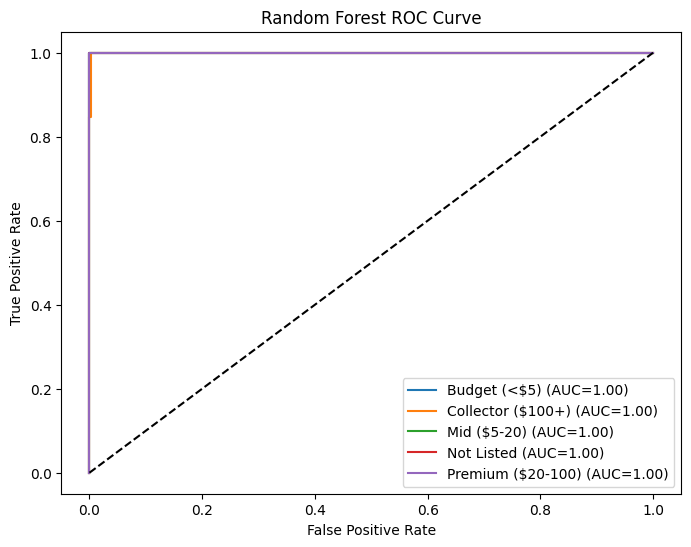



Support Vector Machine
Accuracy : 0.412
Precision: 0.169744
Recall   : 0.412
F1 Score : 0.24043059490084986

Classification Report

                   precision    recall  f1-score   support

     Budget (<$5)       0.41      1.00      0.58       206
Collector ($100+)       0.00      0.00      0.00        13
      Mid ($5-20)       0.00      0.00      0.00       161
       Not Listed       0.00      0.00      0.00        44
Premium ($20-100)       0.00      0.00      0.00        76

         accuracy                           0.41       500
        macro avg       0.08      0.20      0.12       500
     weighted avg       0.17      0.41      0.24       500



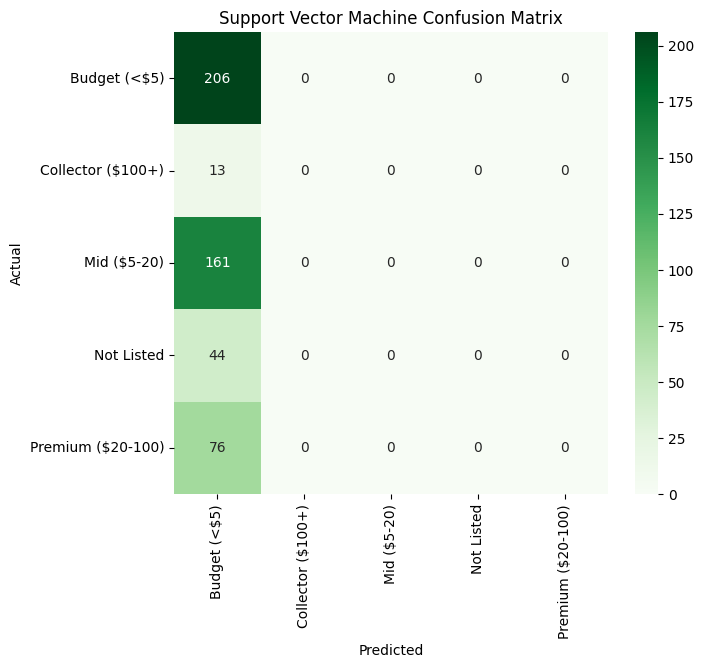

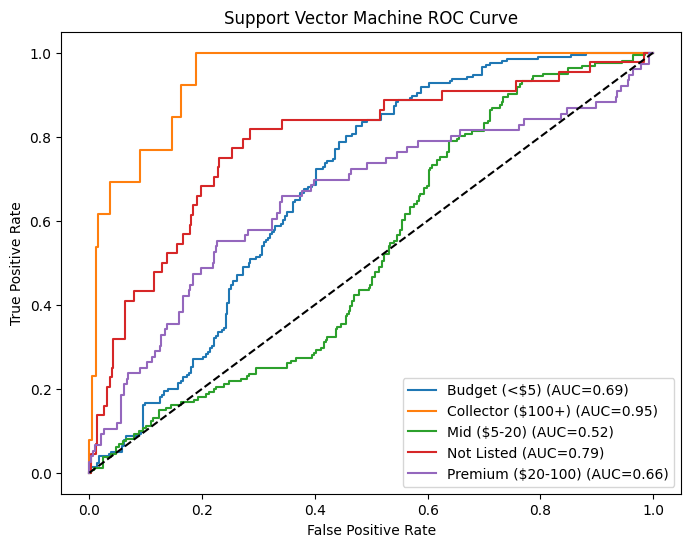



Gaussian Naive Bayes
Accuracy : 0.882
Precision: 0.8911030886548167
Recall   : 0.882
F1 Score : 0.8828765207948999

Classification Report

                   precision    recall  f1-score   support

     Budget (<$5)       0.94      0.90      0.92       206
Collector ($100+)       0.69      0.85      0.76        13
      Mid ($5-20)       0.79      0.91      0.85       161
       Not Listed       1.00      0.95      0.98        44
Premium ($20-100)       0.93      0.74      0.82        76

         accuracy                           0.88       500
        macro avg       0.87      0.87      0.87       500
     weighted avg       0.89      0.88      0.88       500



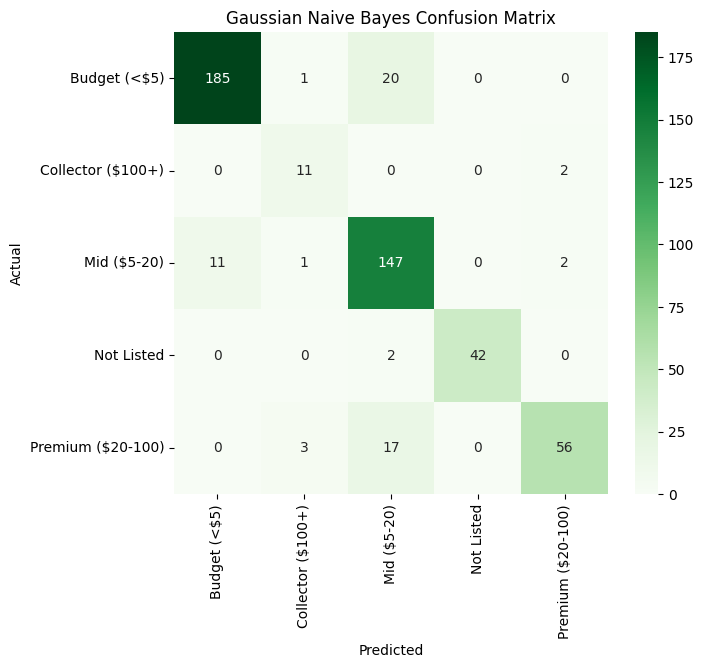

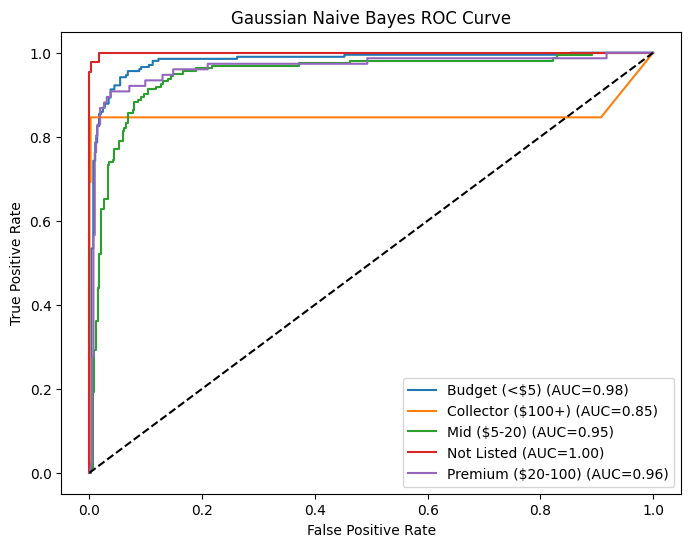



FINAL MODEL COMPARISON
                    Model  Accuracy  Precision  Recall  F1 Score
0           Random Forest     0.984   0.985524   0.984  0.981818
2    Gaussian Naive Bayes     0.882   0.891103   0.882  0.882877
1  Support Vector Machine     0.412   0.169744   0.412  0.240431


In [15]:
# ==========================================================
# ADDITIONAL MODELS
# ==========================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, label_binarize

# ==========================================================
# Encode Target for ROC
# ==========================================================

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

n_classes = len(label_encoder.classes_)

# ==========================================================
# MODELS
# ==========================================================

models = {

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "Support Vector Machine":
        SVC(
            probability=True,
            random_state=42
        ),

    "Gaussian Naive Bayes":
        GaussianNB()
}

results = []

# ==========================================================
# TRAINING
# ==========================================================

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train_encoded)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test_encoded, y_pred)

    precision = precision_score(
        y_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("\n")
    print("="*70)
    print(name)
    print("="*70)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report\n")

    print(classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_
    ))

    # ==========================================
    # Confusion Matrix
    # ==========================================

    cm = confusion_matrix(y_test_encoded, y_pred)

    plt.figure(figsize=(7,6))

    sns.heatmap(
        cm,
        annot=True,
        cmap="Greens",
        fmt="d",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(name + " Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # ==========================================
    # ROC Curve
    # ==========================================

    y_score = pipeline.predict_proba(X_test)

    y_test_bin = label_binarize(
        y_test_encoded,
        classes=np.arange(n_classes)
    )

    plt.figure(figsize=(8,6))

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{label_encoder.classes_[i]} (AUC={roc_auc:.2f})"
        )

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(name + " ROC Curve")

    plt.legend()

    plt.show()

# ==========================================================
# FINAL MODEL COMPARISON
# ==========================================================

comparison = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]

)

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

print(comparison)

## Thanks.................Please Upvote